**1 - MOUNT DRIVE & IMPORT LIBRARY**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt

base_label = '/content/drive/MyDrive/SKRIPSI/CODE/HASIL_ANOTASI'
base_raw   = '/content/drive/MyDrive/SKRIPSI/CODE/CRAWLING DATA/DATA AKHIR'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. LOAD FILE HASIL LABELLING**

In [8]:
df_l1 = pd.read_csv(f'{base_label}/anotator1_fase1_consensus.csv')
df_l1['fase'] = 'Pra-Implementasi'
df_l1['sumber'] = 'anotator1_fase1_consensus'

df_l2 = pd.read_excel(f'{base_label}/anotator1_fase2.xlsx')
df_l2['fase'] = 'Implementasi'
df_l2['sumber'] = 'anotator1_fase2'

df_l3 = pd.read_excel(f'{base_label}/anotator2_fase2.xlsx')
df_l3['fase'] = 'Implementasi'
df_l3['sumber'] = 'anotator2_fase2'

df_label = pd.concat([df_l1, df_l2, df_l3], ignore_index=True)
print("Total data label:", len(df_label))

Total data label: 2539


**3. LOAD FILE DATA MENTAH**

In [9]:
df_r1 = pd.read_csv(f'{base_raw}/Fase1_Pra_Implementasi_MBG.csv')
df_r2 = pd.read_csv(f'{base_raw}/Fase2_Implementasi_MBG.csv')
df_raw = pd.concat([df_r1, df_r2], ignore_index=True)
print("Total data mentah:", len(df_raw))

Total data mentah: 5110


**4. MATCHING BERDASARKAN full_text (id_str tidak reliable, presisi rusak)**

In [10]:
# STEP 4 - MATCHING (dengan cleaning newline & whitespace)
def clean_text(text):
    if pd.isna(text):
        return text
    return ' '.join(text.split())  # hapus semua \n, \t, spasi berlebih

df_label['full_text'] = df_label['full_text'].apply(clean_text)

df_raw_unique = df_raw.drop_duplicates(subset='full_text', keep='first').copy()
df_raw_unique['full_text'] = df_raw_unique['full_text'].apply(clean_text)

df_merged = df_label.merge(
    df_raw_unique[['full_text', 'created_at']],
    on='full_text',
    how='left'
)

print("Berhasil match:", df_merged['created_at'].notna().sum(), "dari", len(df_merged))
gagal = df_merged[df_merged['created_at'].isna()]
print("Baris gagal match:", len(gagal))

if len(gagal) > 0:
    print("\nIsi baris gagal match:")
    print(gagal[['full_text']].values)

df_final = df_merged.dropna(subset=['created_at']).copy()
df_final['created_at'] = pd.to_datetime(df_final['created_at'])

Berhasil match: 2539 dari 2539
Baris gagal match: 0


**5. RINGKASAN POLA SARKASME PER FASE**

In [11]:
ringkasan = df_final.groupby(['fase', 'label']).size().unstack(fill_value=0)
ringkasan['total'] = ringkasan.sum(axis=1)
ringkasan['persen_sarkasme'] = (ringkasan[1] / ringkasan['total'] * 100).round(2)
print(ringkasan)

label                0    1  total  persen_sarkasme
fase                                               
Implementasi      1363  316   1679            18.82
Pra-Implementasi   800   60    860             6.98


**6. LINE CHART TREN MINGGUAN**


=== Tabel Tren Mingguan ===
label       total  sarkasme  persen_sarkasme
minggu                                      
2024-10-28     27         0             0.00
2024-11-04     41         0             0.00
2024-11-11    115        11             9.57
2024-11-18     46         0             0.00
2024-11-25    158        15             9.49
2024-12-02     43         2             4.65
2024-12-09    201        17             8.46
2024-12-16     43         4             9.30
2024-12-23     76         7             9.21
2024-12-30    110         4             3.64
2025-01-06    131        22            16.79
2025-01-13    208        48            23.08
2025-01-20     56         7            12.50
2025-01-27     91        18            19.78
2025-02-03     65         1             1.54
2025-02-10    261        79            30.27
2025-02-17     48        11            22.92
2025-02-24    241        44            18.26
2025-03-03     47         4             8.51
2025-03-10    277        4

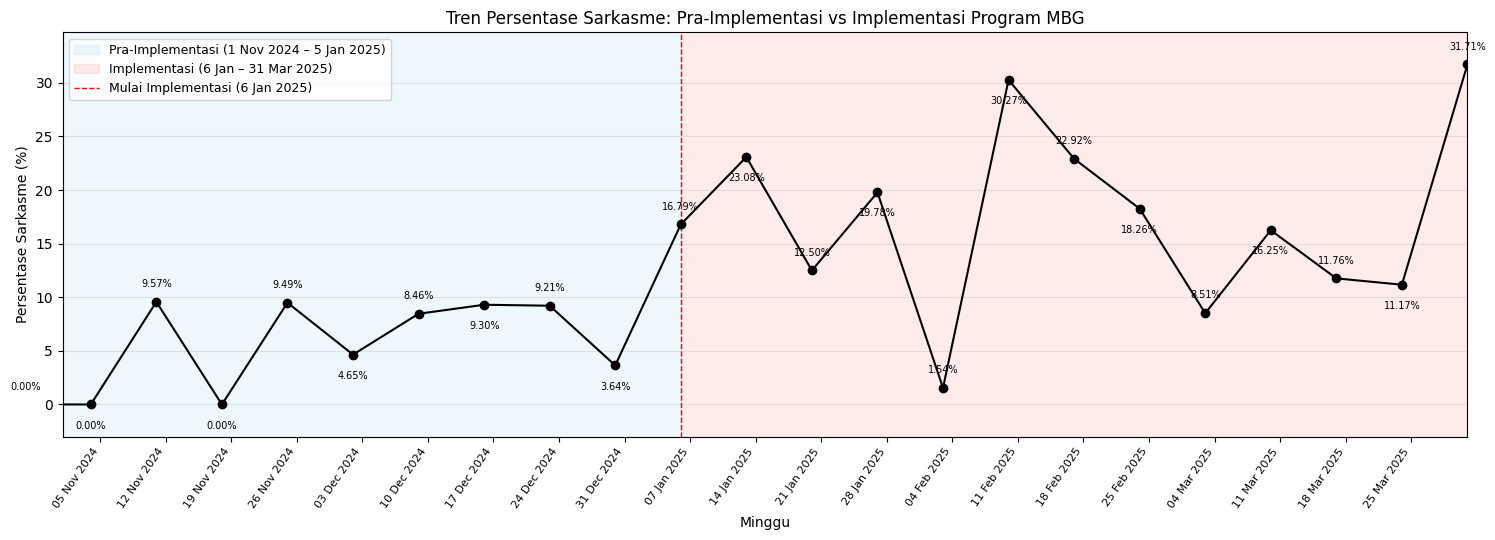

In [22]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

output_dir = '/content/drive/MyDrive/SKRIPSI/CODE/HASIL_ANALISIS_FASE'
os.makedirs(output_dir, exist_ok=True)

# ===== PREPROCESSING =====
df_final['created_at'] = df_final['created_at'].dt.tz_localize(None)
df_final['minggu'] = df_final['created_at'].dt.to_period('W').dt.start_time

# ===== AGREGASI =====
tren = df_final.groupby(['minggu', 'label']).size().unstack(fill_value=0)
tren['total'] = tren.sum(axis=1)
tren['persen_sarkasme'] = (tren[1] / tren['total'] * 100).round(2)

print("\n=== Tabel Tren Mingguan ===")
print(tren[['total', 1, 'persen_sarkasme']].rename(columns={1:'sarkasme'}))

# ===== BATAS FASE =====
awal_pra     = pd.Timestamp('2024-11-01')
batas_fase   = pd.Timestamp('2025-01-06')
akhir_implem = pd.Timestamp('2025-03-31')

plt.figure(figsize=(15, 5.5))

# ===== BACKGROUND FASE =====
plt.axvspan(awal_pra, batas_fase, color='skyblue', alpha=0.15,
            label='Pra-Implementasi (1 Nov 2024 – 5 Jan 2025)')
plt.axvspan(batas_fase, akhir_implem, color='salmon', alpha=0.15,
            label='Implementasi (6 Jan – 31 Mar 2025)')

# ===== GARIS UTAMA =====
plt.plot(tren.index, tren['persen_sarkasme'],
         marker='o', color='black', linewidth=1.5, zorder=3)

# ===== GARIS BATAS =====
plt.axvline(batas_fase, color='red', linestyle='--', linewidth=1,
            label='Mulai Implementasi (6 Jan 2025)')

# ===== LABEL =====
for i, (x, y) in enumerate(zip(tren.index, tren['persen_sarkasme'])):

    offset = 1.2 if i % 2 == 0 else -1.5

    plt.text(
        x,
        y + offset,
        f'{y:.2f}%',
        ha='center',
        va='bottom' if offset > 0 else 'top',
        fontsize=7
    )

# ===== FORMAT AXIS =====
plt.xlabel('Minggu')
plt.ylabel('Persentase Sarkasme (%)')
plt.title('Tren Persentase Sarkasme: Pra-Implementasi vs Implementasi Program MBG')

y_min = tren['persen_sarkasme'].min()
y_max = tren['persen_sarkasme'].max()
plt.ylim(y_min - 3, y_max + 3)

plt.xlim(awal_pra, akhir_implem)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))

plt.xticks(rotation=55, ha='right', fontsize=8)

# ===== STYLE =====
plt.legend(loc='upper left', fontsize=9)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

# ===== SAVE =====
plt.savefig(f'{output_dir}/tren_mingguan_sarkasme_v3.png',
            dpi=150, bbox_inches='tight')

plt.show()

**6A- SAMPLE TWEET DI MINGGU LONJAKAN EKSTRIM**

In [16]:
# ── Otomatis deteksi minggu lonjakan ekstrim + ambil rentang tweetnya ──

# Ambil top N minggu dengan persentase tertinggi
TOP_N = 2  # bisa diganti 3 kalau mau 3 puncak

top_minggu = tren['persen_sarkasme'].nlargest(TOP_N)
print("=== Minggu Puncak Terdeteksi ===")
print(top_minggu)

all_samples = []

for i, (minggu_puncak, persen) in enumerate(top_minggu.items(), start=1):

    # Otomatis ambil 2 minggu sebelum puncak s/d minggu puncak itu sendiri
    tgl_selesai = minggu_puncak + pd.Timedelta(days=6)   # akhir minggu puncak
    tgl_mulai   = minggu_puncak - pd.Timedelta(weeks=1)  # 1 minggu sebelumnya

    mask = (
        (df_final['created_at'] >= tgl_mulai) &
        (df_final['created_at'] <= tgl_selesai) &
        (df_final['label'] == 1)
    )
    df_rentang = df_final[mask].copy()
    n_sample   = min(15, len(df_rentang))

    if n_sample == 0:
        print(f"\n⚠️  Lonjakan {i}: tidak ada tweet sarkasme di rentang ini.")
        continue

    sample = df_rentang[['created_at', 'full_text']].sample(n=n_sample, random_state=42).copy()
    sample['lonjakan']  = f'Lonjakan {i} - {minggu_puncak.strftime("%b %Y")}'
    sample['rentang']   = f"{tgl_mulai.strftime('%d %b %Y')} s/d {tgl_selesai.strftime('%d %b %Y')}"
    sample['persen_puncak'] = f"{persen}%"
    all_samples.append(sample)

    print(f"\n{'='*65}")
    print(f"📅 Lonjakan {i} | Puncak: {minggu_puncak.strftime('%d %b %Y')} ({persen}%)")
    print(f"   Rentang otomatis : {tgl_mulai.strftime('%d %b %Y')} s/d {tgl_selesai.strftime('%d %b %Y')}")
    print(f"   Total tweet sarkasme di rentang : {len(df_rentang)}")
    print(f"{'='*65}")
    for _, row in sample.sort_values('created_at').iterrows():
        print(f"\n  [{row['created_at'].strftime('%d %b %Y')}]")
        print(f"  {row['full_text']}")

# ── Export ke Excel otomatis ──
if all_samples:
    df_export = pd.concat(all_samples, ignore_index=True)
    df_export = df_export.sort_values(['lonjakan', 'created_at'])
    df_export.to_excel(f'{output_dir}/sample_tweet_lonjakan_ekstrim2.xlsx', index=False)
    print(f"\n✅ Tersimpan: {output_dir}/sample_tweet_lonjakan_ekstrim2.xlsx")

=== Minggu Puncak Terdeteksi ===
minggu
2025-03-31    31.71
2025-02-10    30.27
Name: persen_sarkasme, dtype: float64

📅 Lonjakan 1 | Puncak: 31 Mar 2025 (31.71%)
   Rentang otomatis : 24 Mar 2025 s/d 06 Apr 2025
   Total tweet sarkasme di rentang : 33

  [29 Mar 2025]
  Yauda, hapus aja program MBG sm Danantara dananya dialihin buat hapus kemiskinan

  [29 Mar 2025]
  Dapur MBG sedang tidak baik-baik saja… Akhirnya Dapur MBG di Lamaka, Bantaeng mengundurkan diri dan angkut barangnya… Katanya program MBG sekalian buat bantu UMKM, bantu apanya kalau pembayaran terlambat, belum lagi disunat untuk ini itu! UMKM itu memangnya tidak beli https://t.co/vXAagKxONO

  [30 Mar 2025]
  tau kan knp getol bgt sm program mbg? disamping utk getol soal pendidikan dan bbrp sektor vital lainnya yg menunjang roda ekonomi? soalnya itu bikin sdm yg well-educated dan ber-ekonomi cukup, yg dmn itu ancaman bagi mulyono and the gank, terutama si wapres ipk dua koma tiga

  [30 Mar 2025]
  Makan bergizi gratis 

**7. GROUPED BAR CHART PER FASE**

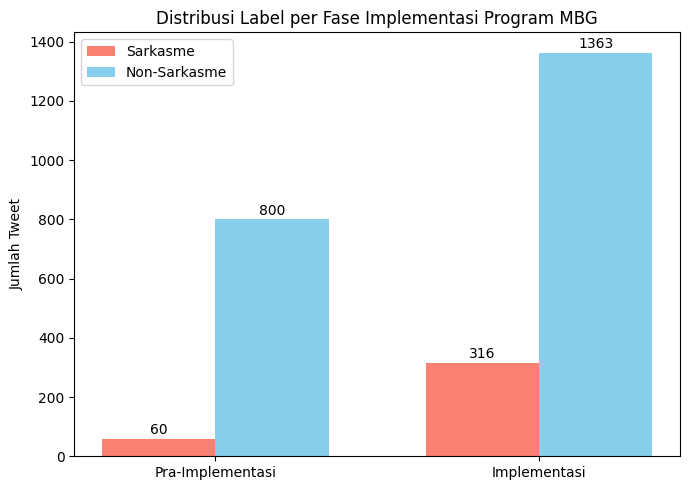

label                0    1  total  persen_sarkasme
fase                                               
Implementasi      1363  316   1679            18.82
Pra-Implementasi   800   60    860             6.98


In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np

output_dir = '/content/drive/MyDrive/SKRIPSI/CODE/HASIL_ANALISIS_FASE'
os.makedirs(output_dir, exist_ok=True)

fase_label   = ['Pra-Implementasi', 'Implementasi']
sarkasme     = [ringkasan.loc['Pra-Implementasi', 1], ringkasan.loc['Implementasi', 1]]
non_sarkasme = [ringkasan.loc['Pra-Implementasi', 0], ringkasan.loc['Implementasi', 0]]

x = np.arange(len(fase_label))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, sarkasme,     width, label='Sarkasme',     color='salmon')
bars2 = ax.bar(x + width/2, non_sarkasme, width, label='Non-Sarkasme', color='skyblue')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(fase_label)
ax.set_ylabel('Jumlah Tweet')
ax.set_title('Distribusi Label per Fase Implementasi Program MBG')
ax.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/distribusi_per_fase.png', dpi=150, bbox_inches='tight')
plt.show()

print(ringkasan)